## 리텐션이 높은 코호트의 특징 분석
### 가설 설정

앞서 분석을 통해 리텐션이 높은 코호트는 단순히 평균 값이 높은 것이 아니라,  
여러 Range 구간에 걸쳐 **재구매 패턴이 지속적으로 나타나는 특징**을 보였다.

| 순위 | 코호트(첫 구매 기준) | R1 | R2 | R3 | R4 | 평균 리텐션 | 전체 평균 대비 |
|------|--------|-----|-----|-----|-----|------------|---------------|
| 1위 | 2024-05 | 10.6% | 10.9% | - | - | **10.75%** | **+36.1%** |
| 2위 | 2024-03 | 10.9% | 9.6% | 9.6% | - | **10.01%** | **+26.7%** |
| - | 전체 평균 | - | - | - | - | 7.90% | - |

이러한 차이는 고객의 구매 행동, 가격 민감도, 상품 선호도 등의 요인에서 기인할 가능성이 있다.  
따라서 본 분석에서는 리텐션 차이를 설명할 수 있는 주요 요인을 다음과 같은 가설을 통해 검증하고자 한다.

### **가설1. 리텐션이 높은 코호트의 결제 방식 비율은 전체 코호트와 상이할 것이다.**   
→ 결제 방식은 고객의 구매 편의성 및 충성도와 관련이 있으며, 특정 결제 수단을 사용하는 고객이 더 높은 재구매율을 보일 가능성이 있다.

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()  # .env 파일 로드

# MySQL 연결
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)


# 첫 구매 월이 3월, 5월인 고객들만 추출
query_2024 = """
    WITH first_purchases AS (
        SELECT 
            CustomerID,
            MIN(OrderDate) AS first_purchase_date,
            DATE_FORMAT(MIN(OrderDate), '%Y-%m') AS first_purchase_month
        FROM orders_info
        GROUP BY CustomerID
    )
    SELECT 
    	o.OrderDate,
    	o.CustomerID,
    	f.first_purchase_date,
    	f.first_purchase_month,
    	TIMESTAMPDIFF(MONTH, f.first_purchase_date, o.OrderDate) AS month_diff,
        o.PaymentMethod
    FROM orders_info o
    LEFT JOIN first_purchases f ON o.CustomerID = f.CustomerID
    WHERE YEAR(f.first_purchase_date) = 2024
    ORDER BY o.OrderDate
"""

first_purchase_all = pd.read_sql(query_2024, engine)

In [2]:
first_purchase_all.head()

,OrderDate,CustomerID,first_purchase_date,first_purchase_month,month_diff,PaymentMethod
0,2024-01-01,CUST017399,2024-01-01,2024-01,0,Debit Card
1,2024-01-01,CUST016412,2024-01-01,2024-01,0,Amazon Pay
2,2024-01-01,CUST033266,2024-01-01,2024-01,0,Debit Card
3,2024-01-01,CUST028551,2024-01-01,2024-01,0,Debit Card
4,2024-01-01,CUST032020,2024-01-01,2024-01,0,Credit Card


In [32]:
first_purchase_all['first_purchase_month'] = pd.to_datetime(first_purchase_all['first_purchase_month'])

In [33]:
first_purchase_all.shape

(3944, 6)

In [34]:
first_purchase_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3944 entries, 0 to 3943
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   OrderDate             3944 non-null   datetime64[ns]
 1   CustomerID            3944 non-null   object        
 2   first_purchase_date   3944 non-null   datetime64[ns]
 3   first_purchase_month  3944 non-null   datetime64[ns]
 4   month_diff            3944 non-null   int64         
 5   PaymentMethod         3944 non-null   object        
dtypes: datetime64[ns](3), int64(1), object(2)
memory usage: 185.0+ KB


In [35]:
first_purchase_all['CustomerID'].nunique()

3262

In [36]:
first_purchase_all['PaymentMethod'].unique()

array(['Debit Card', 'Amazon Pay', 'Credit Card', 'Cash on Delivery',
       'UPI', 'Net Banking'], dtype=object)

In [37]:
first_purchase_all['PaymentMethod'].value_counts()

PaymentMethod
Credit Card         1415
Debit Card           786
Amazon Pay           601
UPI                  587
Net Banking          347
Cash on Delivery     208
Name: count, dtype: int64

### 결제 방식 종류
- 결제 방식의 종류를 확인해본 결과 총 6개의 결제 방식이 존재하였다.

- **Cash on Delivery (COD)**  
  - 상품을 배송받은 후, 현금 또는 카드로 결제하는 방식  
  - 온라인 선결제에 대한 부담이 있는 고객들이 주로 선택

- **Debit Card**  
  - 체크카드를 이용한 결제 방식  
  - 결제 시점에 계좌에서 즉시 금액이 출금되는 구조

- **Credit Card**  
  - 신용카드를 이용한 결제 방식  
  - 후불 결제이며, 할부 및 카드 혜택(포인트, 캐시백 등)을 활용할 수 있음

- **UPI (Unified Payments Interface)**  
  - 인도 기반의 실시간 계좌이체 결제 시스템  
  - 모바일 앱을 통해 간편하게 송금 및 결제가 가능

- **Net Banking**  
  - 인터넷 뱅킹을 통해 직접 계좌이체로 결제하는 방식  
  - 카드 없이 은행 계정을 통해 결제 진행

- **Amazon Pay**  
  - 아마존의 간편 결제 서비스  
  - 계정에 등록된 카드 또는 잔액을 통해 빠르게 결제 가능

In [21]:
# 첫 구매 월이 3월, 5월인 고객들만 추출
query_3_5 = """
    WITH first_purchases AS (
        SELECT 
            CustomerID,
            MIN(OrderDate) AS first_purchase_date,
            DATE_FORMAT(MIN(OrderDate), '%Y-%m') AS first_purchase_month
        FROM orders_info
        GROUP BY CustomerID
    )
    SELECT 
    	o.OrderDate,
    	o.CustomerID,
    	f.first_purchase_date,
    	f.first_purchase_month,
    	TIMESTAMPDIFF(MONTH, f.first_purchase_date, o.OrderDate) AS month_diff,
        o.PaymentMethod
    FROM orders_info o
    LEFT JOIN first_purchases f ON o.CustomerID = f.CustomerID
    WHERE f.first_purchase_month IN ('2024-03', '2024-05') 
    ORDER BY o.OrderDate
"""

first_purchase_3_5 = pd.read_sql(query_3_5, engine)

In [22]:
first_purchase_3_5.head()

,OrderDate,CustomerID,first_purchase_date,first_purchase_month,month_diff,PaymentMethod
0,2024-03-01,CUST039504,2024-03-01,2024-03,0,Cash on Delivery
1,2024-03-01,CUST010943,2024-03-01,2024-03,0,Debit Card
2,2024-03-01,CUST029980,2024-03-01,2024-03,0,Credit Card
3,2024-03-01,CUST021013,2024-03-01,2024-03,0,Credit Card
4,2024-03-01,CUST024559,2024-03-01,2024-03,0,Debit Card


In [23]:
first_purchase_3_5['first_purchase_month'] = pd.to_datetime(first_purchase_3_5['first_purchase_month'])

In [24]:
first_purchase_3_5.shape

(790, 6)

In [25]:
first_purchase_3_5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790 entries, 0 to 789
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   OrderDate             790 non-null    datetime64[ns]
 1   CustomerID            790 non-null    object        
 2   first_purchase_date   790 non-null    datetime64[ns]
 3   first_purchase_month  790 non-null    datetime64[ns]
 4   month_diff            790 non-null    int64         
 5   PaymentMethod         790 non-null    object        
dtypes: datetime64[ns](3), int64(1), object(2)
memory usage: 37.2+ KB


In [26]:
first_purchase_3_5['CustomerID'].nunique()

596

In [27]:
first_purchase_3_5['PaymentMethod'].unique()

array(['Cash on Delivery', 'Debit Card', 'Credit Card', 'UPI',
       'Net Banking', 'Amazon Pay'], dtype=object)

In [28]:
first_purchase_3_5['PaymentMethod'].value_counts()

PaymentMethod
Credit Card         295
Debit Card          140
Amazon Pay          121
UPI                 108
Net Banking          77
Cash on Delivery     49
Name: count, dtype: int64

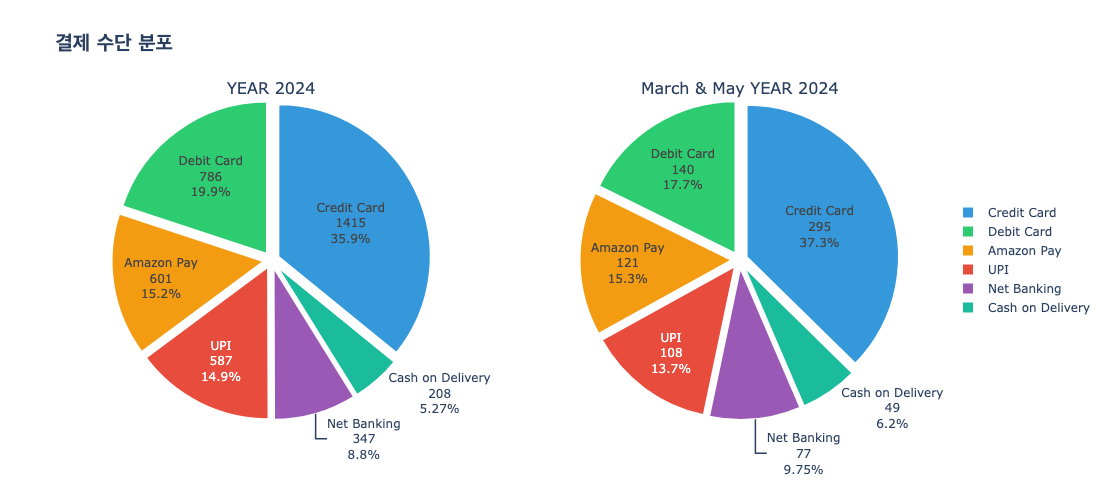

In [41]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 데이터 준비
payment_counts_all = first_purchase_all['PaymentMethod'].value_counts()
payment_counts_3_5 = first_purchase_3_5['PaymentMethod'].value_counts()

fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=("YEAR 2024", "March & May YEAR 2024"),
    specs=[[{"type": "pie"}, {"type": "pie"}]]  
)

fig.add_trace(
    go.Pie(
        labels=payment_counts_all.index,
        values=payment_counts_all.values,
        textinfo='label+percent+value',
        textposition='auto',
        insidetextorientation='horizontal',
        marker=dict(
            colors=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c'],  # 색상
            line=dict(color='white', width=2)  # 테두리
        ),
        hovertemplate='<b>%{label}</b><br>건수: %{value:,}<br>비율: %{percent}<extra></extra>',
        pull=[0.05] * len(payment_counts_all)  # 약간 분리 효과
    ),
    row=1,
    col=1
)


fig.add_trace(
    go.Pie(
        labels=payment_counts_3_5.index,
        values=payment_counts_3_5.values,
        textinfo='label+percent+value',
        textposition='auto',
        insidetextorientation='horizontal',
        marker=dict(
            colors=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c'],  # 색상
            line=dict(color='white', width=2)  # 테두리
        ),
        hovertemplate='<b>%{label}</b><br>건수: %{value:,}<br>비율: %{percent}<extra></extra>',
        pull=[0.05] * len(payment_counts_3_5)  # 분리 효과
    ),
    row=1,
    col=2
)

fig.update_layout(
    title=dict(
        text='<b>결제 수단 분포</b>',
        font=dict(size=20)
    ),
    height=500,
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.02
    )
)

fig.show()

## 가설 1: 결제 수단 분포 비교 분석

### 가설
**리텐션이 높은 코호트의 결제 방식 비율은 전체 코호트와 상이할 것이다.**

결제 방식은 고객의 구매 편의성 및 충성도와 관련이 있으며, 특정 결제 수단을 사용하는 고객이 더 높은 재구매율을 보일 가능성이 있다.

---

### 분석 결과

#### 결제 수단별 건수

| 결제 수단 | 리텐션이 높은 코호트 | 2024 전체 |
|-----------|----------------|-----------|
| Credit Card | 295건 | 1,415건 |
| Debit Card | 140건 | 786건 |
| Amazon Pay | 121건 | 601건 |
| UPI | 108건 | 587건 |
| Net Banking | 77건 | 347건 |
| Cash on Delivery | 49건 | 208건 |
| **합계** | **790건** | **3,944건** |

#### 결제 수단별 비율

| 결제 수단 | 리텐션이 높은 코호트 | 2024 전체 | 차이 |
|-----------|----------------|-----------|------|
| Credit Card | 37.3% | 35.9% | **+1.4%p** |
| Debit Card | 17.7% | 19.9% | -2.2%p |
| Amazon Pay | 15.3% | 15.2% | +0.1%p |
| UPI | 13.7% | 14.9% | -1.2%p |
| Net Banking | 9.75% | 8.8% | +0.95%p |
| Cash on Delivery | 6.2% | 5.27% | +0.93%p |

리텐션이 높은 코호트와 전체 코호트 간 결제 수단 분포의 차이는 **매우 작음** (최대 2.2%p). 주요 결제 수단의 순위도 동일하며, 전반적인 패턴이 거의 일치함.

---

### 가설 검증 결과

**가설 기각**

결제 수단 분포는 유의미한 차이가 없으며, 결제 방식은 리텐션에 **직접적인 영향을 주는 주요 요인이 아님**으로 판단됨.

---

### 추가 분석: 선결제 vs 후결제

결제 수단을 결제 시점 기준으로 재분류:

- **선결제 (Pre-payment):** Credit Card + Debit Card + Amazon Pay + UPI + Net Banking
- **후결제 (Post-payment):** Cash on Delivery

#### 건수

| 구분 | 리텐션이 높은 코호트 | 2024 전체 |
|------|----------------|-----------|
| 선결제 | 741건 | 3,736건 |
| 후결제 | 49건 | 208건 |
| **합계** | **790건** | **3,944건** |

#### 비율

| 구분 | 리텐션이 높은 코호트 | 2024 전체 | 차이 |
|------|----------------|-----------|------|
| 선결제 | 93.8% | 94.73% | -0.93%p |
| 후결제 | 6.2% | 5.27% | +0.93%p |

두 그룹 모두 **선결제가 약 94%** 를 차지하므로, 선결제 중심의 결제 편의성 유지가 중요함.

---

## 💡 제언

결제 수단이 리텐션의 주요 차별화 요인은 아니지만, **기본적인 결제 편의성 유지는 필수적**임.

### 선결제 편의성 강화

두 그룹 모두 선결제 비율이 94%로 압도적이므로:

1. **원클릭 결제 기능 유지**
   - 저장된 결제 수단으로 빠른 재구매 지원
   - 결제 과정 간소화로 구매 전환율 향상

2. **다양한 디지털 결제 수단 지원**
   - Apple Pay, Google Pay 등 간편결제 추가
   - 고객 선호도에 맞는 결제 옵션 제공

3. **결제 보상 프로그램**
   - Credit Card 결제 시 추가 포인트 적립 (현재 37% 비중)
   - 첫 구매 시 디지털 결제 선택 시 할인 쿠폰 제공